### Chemins

In [1]:
from pathlib import Path
import pandas as pd

def find_root():
    p = Path.cwd()
    for parent in [p, *p.parents]:
        if (parent/"data"/"processed").exists() and (parent/"scripts").exists():
            return parent
    raise FileNotFoundError("Racine projet introuvable")

ROOT = find_root()
PROC = ROOT / "data" / "processed"
FIGS = PROC / "figures"; FIGS.mkdir(exist_ok=True)

print("ROOT =", ROOT)


ROOT = c:\Users\Wouaff\memoire-clients-influents


### Chargement & check

In [2]:
s = pd.read_csv(PROC/"absa_macro_summary_fr.csv")
counts = pd.read_csv(PROC/"absa_macro_by_hotel_counts_fr.csv", index_col=0)
meanz  = pd.read_csv(PROC/"absa_macro_by_hotel_mean_fr.csv", index_col=0)
print("Somme des pct =", s["pct"].sum().round(3))
s


Somme des pct = 1.0


,macro_topic,n,mean_z,pct_influents,pct
0,Accueil / Service,470,0.660638,0.121277,0.242143
1,Chambre / Confort,436,0.175459,0.071101,0.224626
2,Localisation / Transports,427,0.638173,0.070258,0.219990
3,Petit-déjeuner,262,0.431298,0.064885,0.134982
4,Salle de bain,147,0.224490,0.156463,0.075734
5,Propreté,112,0.633929,0.062500,0.057702
6,Rapport qualité-prix,87,0.477011,0.344828,0.044822


### Heatmap volumes (hôtel × thème)

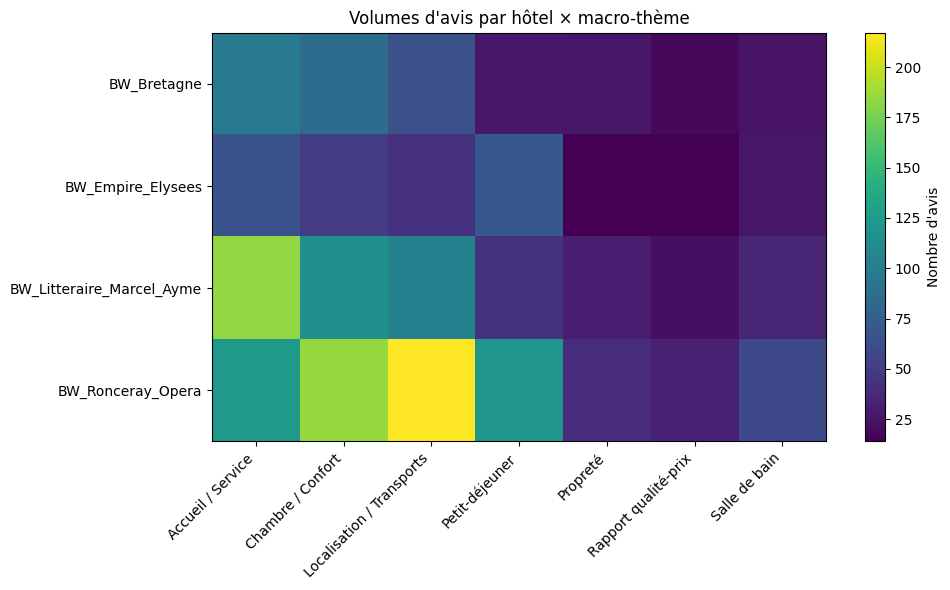

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.imshow(counts.values, aspect="auto")
plt.xticks(range(counts.shape[1]), counts.columns, rotation=45, ha="right")
plt.yticks(range(counts.shape[0]), counts.index)
plt.title("Volumes d'avis par hôtel × macro-thème")
plt.colorbar(label="Nombre d'avis")
plt.tight_layout()
plt.savefig(FIGS/"heatmap_counts.png", dpi=200)
plt.show()


La carte montre où se concentrent les retours : Ronceray Opéra porte l’essentiel sur Localisation/Transports (217) et Chambre/Confort (185), Littéraire Marcel Aymé sur Accueil/Service (184), et Empire Élysées sur Petit-déjeuner (70). Ces volumes indiquent les sujets saillants par hôtel et guident la priorisation des analyses. Opérationnellement, ils servent à dimensionner l’écoute client (ex. staffing accueil, maintenance chambre) là où la pression d’avis est la plus forte.

### Heatmap sentiment moyen (hôtel × thème)

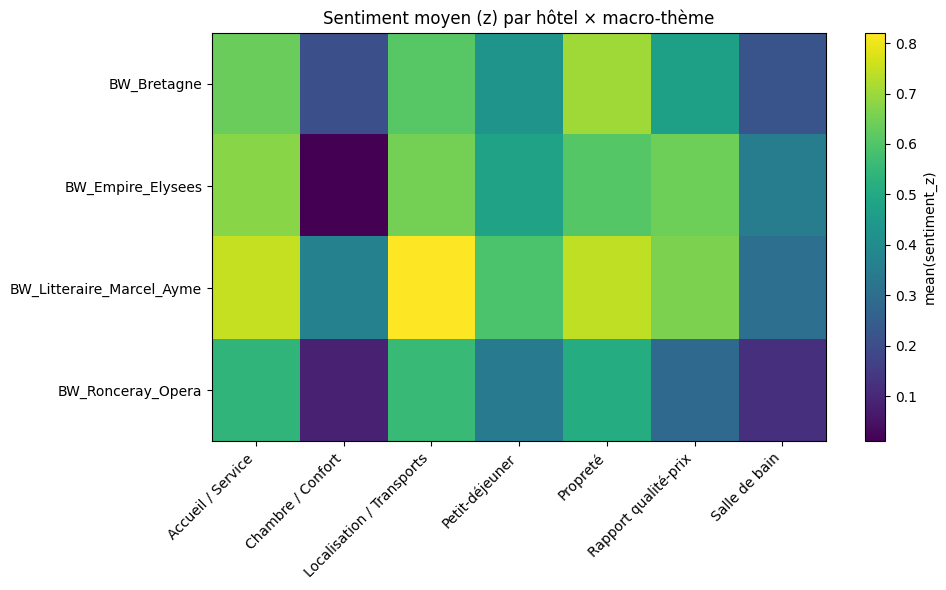

In [4]:
plt.figure(figsize=(10,6))
plt.imshow(meanz.values, aspect="auto")
plt.xticks(range(meanz.shape[1]), meanz.columns, rotation=45, ha="right")
plt.yticks(range(meanz.shape[0]), meanz.index)
plt.title("Sentiment moyen (z) par hôtel × macro-thème")
plt.colorbar(label="mean(sentiment_z)")
plt.tight_layout()
plt.savefig(FIGS/"heatmap_meanz.png", dpi=200)
plt.show()


Les points forts ressortent chez Littéraire Marcel Aymé (Accueil ~0,75 ; Localisation ~0,82 ; Propreté ~0,74). À l’inverse, Ronceray Opéra est faible sur Chambre/Confort (~0,08) et Salle de bain (~0,12), et Empire Élysées frôle le neutre sur Chambre/Confort (~0,01). Bretagne est correct mais perfectible sur Salle de bain (~0,22). Ces écarts orientent des actions ciblées (capex chambres/SDB, insonorisation, contrôle qualité) par établissement.

### Pourcentage d’avis influents par thème

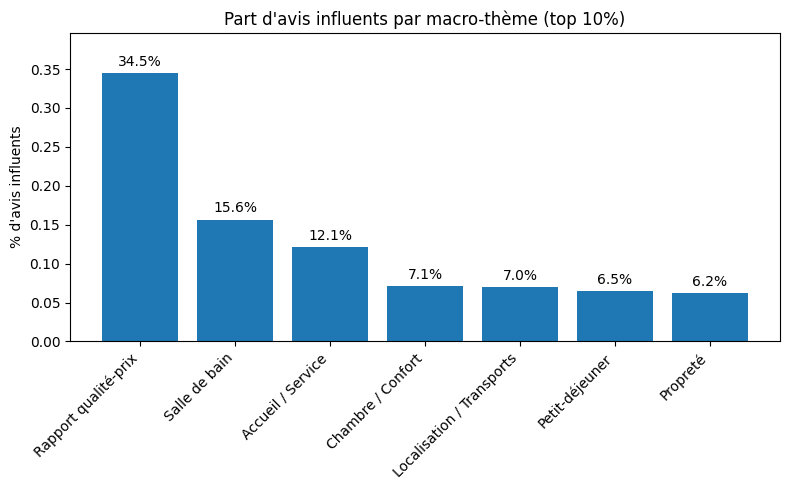

In [7]:
s_plot = s.sort_values("pct_influents", ascending=False)

plt.figure(figsize=(8,5))
bars = plt.bar(s_plot["macro_topic"], s_plot["pct_influents"])

# un peu d'air en haut pour laisser passer les labels
plt.ylim(0, s_plot["pct_influents"].max() * 1.15)

# labels au-dessus de chaque barre
for rect in bars:
    height = rect.get_height()
    plt.annotate(f"{height:.1%}",                      # format en pourcentage
                 xy=(rect.get_x() + rect.get_width()/2, height),
                 xytext=(0, 3), textcoords="offset points",  # décalage de 3px
                 ha="center", va="bottom")

plt.xticks(rotation=45, ha="right")
plt.ylabel("% d'avis influents")
plt.title("Part d'avis influents par macro-thème (top 10%)")
plt.tight_layout()
plt.savefig(FIGS/"bar_pct_influents.png", dpi=200)
plt.show()


Le Rapport qualité-prix concentre la part la plus élevée d’avis influents (~35 %) malgré un volume modeste : c’est un levier réputationnel majeur (offres, transparence, bénéfices perçus). Salle de bain suit (~15,6 %), confirmant un axe de progrès prioritaire. Accueil/Service affiche une part d’influents non négligeable (~12 %) mais sur un ton globalement positif : à capitaliser (formation, rituels d’accueil). Ces résultats relient directement les thèmes aux impacts sur la réputation.

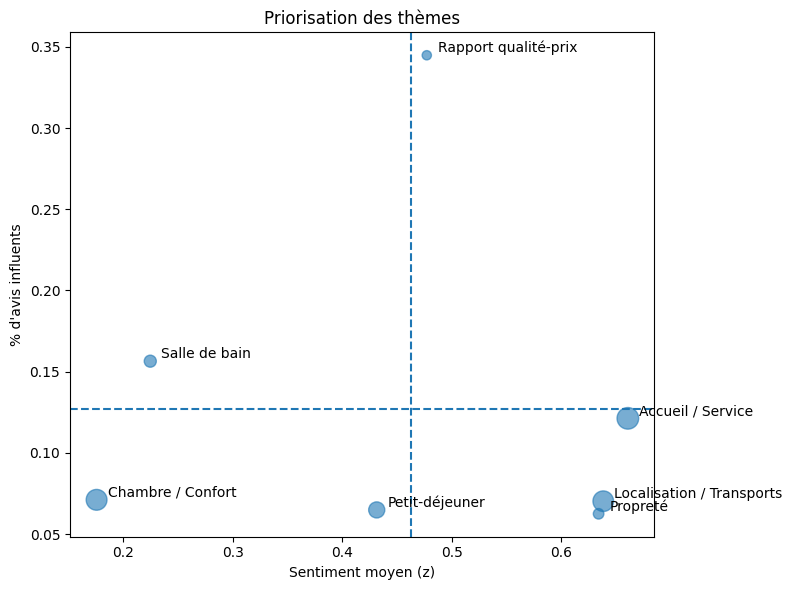

In [8]:
plt.figure(figsize=(8,6))
sizes = 1000 * s["pct"]  # taille ~ part dans le corpus
plt.scatter(s["mean_z"], s["pct_influents"], s=sizes, alpha=0.6)
for _, r in s.iterrows():
    plt.text(r["mean_z"]+0.01, r["pct_influents"]+0.002, r["macro_topic"])
plt.axvline(s["mean_z"].mean(), linestyle="--")
plt.axhline(s["pct_influents"].mean(), linestyle="--")
plt.xlabel("Sentiment moyen (z)")
plt.ylabel("% d'avis influents")
plt.title("Priorisation des thèmes")
plt.tight_layout()
plt.savefig(FIGS/"bubble_priorites.png", dpi=200)
plt.show()


Chaque bulle combine le ton moyen (x), la part d’avis influents (y) et le poids (taille) : le nuage montre ce qui façonne vraiment la réputation.
Deux priorités ressortent : Salle de bain (ton faible ~0,22, influents ~15,6%) → actions rapides de maintenance/checklists ; et surtout Rapport qualité-prix (ton ~0,48, impact le plus élevé ~35%) → repackager l’offre et clarifier la valeur perçue.
Chambre/Confort (ton ~0,18, ~7% influents) relève d’un plan moyen terme (literie, bruit).
À l’inverse, Accueil/Service et Localisation/Propreté (≥0,63, faible % influents) sont des atouts à pérenniser et mettre en avant dans la promesse et les réponses aux avis.